=== ÉVALUATION FINALE DU MODÈLE - Isolation Forest ===

Nombre total de fenêtres testées : 5000
Nombre d'anomalies détectées : 250
Pourcentage d'anomalies : 5.00%


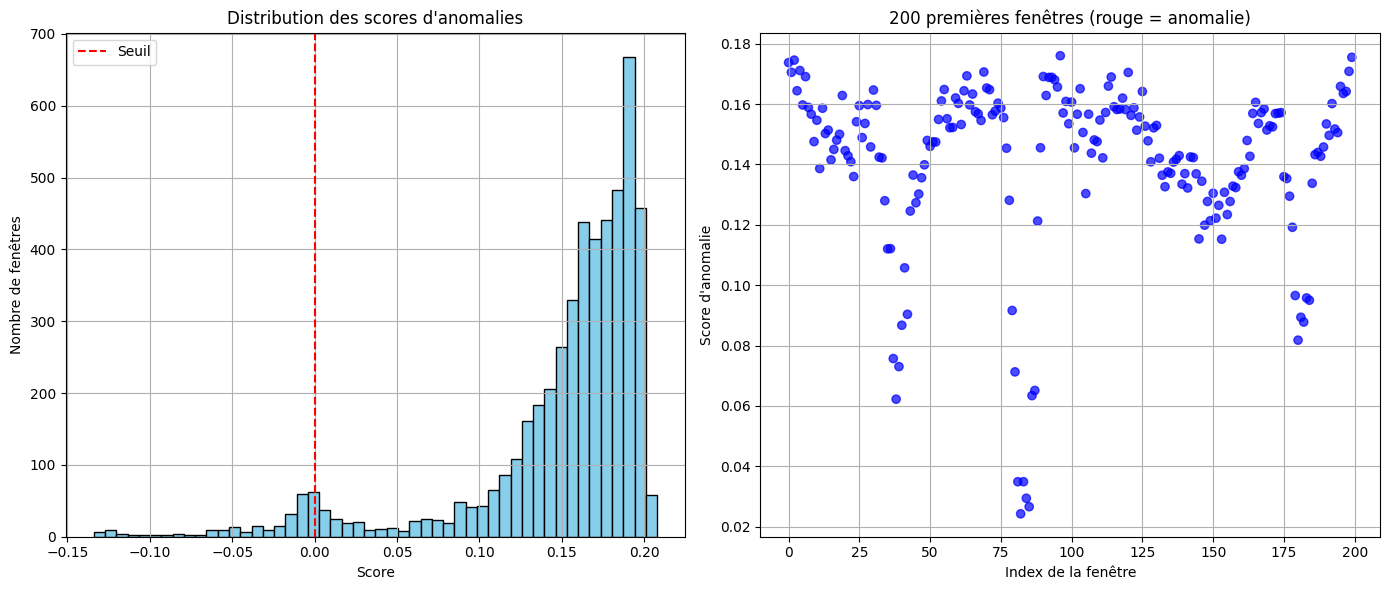


Modèle prêt pour la détection de pannes dans les datacenters.
Points forts du projet :
- Utilisation du dataset SMD réel
- Augmentation des données (4 versions)
- Création de fenêtres temporelles
- Modèle de détection d'anomalies

Résumé sauvegardé dans reports/rapport_summary.txt


In [1]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os

print("=== ÉVALUATION FINALE DU MODÈLE - Isolation Forest ===\n")

# Chargement du modèle et du scaler
model = joblib.load('models/isolation_forest_model.pkl')
scaler = joblib.load('models/scaler.pkl')

# Chargement des données
WINDOWS_PATH = 'data/processed/windows/'
X_windows = np.load(os.path.join(WINDOWS_PATH, 'X_windows.npy'))

# Utiliser les mêmes données que pour l'entraînement
MAX_SAMPLES = 5000
X_test = X_windows[:MAX_SAMPLES]

# Aplatir et normaliser
X_flat = X_test.reshape(X_test.shape[0], -1)
X_scaled = scaler.transform(X_flat)

# Prédiction
predictions = model.predict(X_scaled)        # -1 = anomalie, 1 = normal
anomaly_scores = model.decision_function(X_scaled)

print(f"Nombre total de fenêtres testées : {len(predictions)}")
print(f"Nombre d'anomalies détectées : {(predictions == -1).sum()}")
print(f"Pourcentage d'anomalies : {(predictions == -1).mean()*100:.2f}%")

# ==================== VISUALISATION ====================
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(anomaly_scores, bins=50, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Seuil')
plt.title('Distribution des scores d\'anomalies')
plt.xlabel('Score')
plt.ylabel('Nombre de fenêtres')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(range(len(anomaly_scores[:200])), anomaly_scores[:200], 
            c=['red' if p == -1 else 'blue' for p in predictions[:200]], alpha=0.7)
plt.title('200 premières fenêtres (rouge = anomalie)')
plt.xlabel('Index de la fenêtre')
plt.ylabel('Score d\'anomalie')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nModèle prêt pour la détection de pannes dans les datacenters.")
print("Points forts du projet :")
print("- Utilisation du dataset SMD réel")
print("- Augmentation des données (4 versions)")
print("- Création de fenêtres temporelles")
print("- Modèle de détection d'anomalies")

# Sauvegarde d'un rapport simple
with open('reports/rapport_summary.txt', 'w', encoding='utf-8') as f:
    f.write("Résumé du Projet PFA - Prédiction des états des datacenters\n\n")
    f.write(f"Nombre de fenêtres utilisées : {len(predictions)}\n")
    f.write(f"Anomalies détectées : {(predictions == -1).sum()} ({(predictions == -1).mean()*100:.2f}%)\n")
    f.write("Modèle utilisé : Isolation Forest\n")
    f.write("Dataset : Server Machine Dataset (SMD)\n")

print("\nRésumé sauvegardé dans reports/rapport_summary.txt")